In [1]:
#Research Question: What factors contribute the most to churn?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn import svm, datasets
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import classification_report

In [3]:
pwd

'C:\\Users\\weepo\\pythonlab\\Scripts'

In [4]:
df = pd.read_csv('C:\\Users\\weepo\\Documents\\WGU\\D208 Task 2\\Raw Data\\churn_clean.csv')
#importing the data

In [5]:
df.head()
#this is to test if it worked

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,...,MonthlyCharge,Bandwidth_GB_Year,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,K409198,aa90260b-4141-4a24-8e36-b04ce1f4f77b,e885b299883d4f9fb18e39c75155d990,Point Baker,AK,Prince of Wales-Hyder,99927,56.25100,-133.37571,...,172.455519,904.536110,5,5,5,3,4,4,3,4
1,2,S120509,fb76459f-c047-4a9d-8af9-e0f7d4ac2524,f2de8bef964785f41a2959829830fb8a,West Branch,MI,Ogemaw,48661,44.32893,-84.24080,...,242.632554,800.982766,3,4,3,3,4,3,4,4
2,3,K191035,344d114c-3736-4be5-98f7-c72c281e2d35,f1784cfa9f6d92ae816197eb175d3c71,Yamhill,OR,Yamhill,97148,45.35589,-123.24657,...,159.947583,2054.706961,4,4,2,4,4,3,3,3
3,4,D90850,abfa2b40-2d43-4994-b15a-989b8c79e311,dc8a365077241bb5cd5ccd305136b05e,Del Mar,CA,San Diego,92014,32.96687,-117.24798,...,119.956840,2164.579412,4,4,4,2,5,4,3,3
4,5,K662701,68a861fd-0d20-4e51-a587-8a90407ee574,aabb64a116e83fdc4befc1fbab1663f9,Needville,TX,Fort Bend,77461,29.38012,-95.80673,...,149.948316,271.493436,4,4,4,3,4,4,4,5


In [6]:
df.isnull().sum()
#checking for null values and displaying as a sum

CaseOrder                  0
Customer_id                0
Interaction                0
UID                        0
City                       0
State                      0
County                     0
Zip                        0
Lat                        0
Lng                        0
Population                 0
Area                       0
TimeZone                   0
Job                        0
Children                   0
Age                        0
Income                     0
Marital                    0
Gender                     0
Churn                      0
Outage_sec_perweek         0
Email                      0
Contacts                   0
Yearly_equip_failure       0
Techie                     0
Contract                   0
Port_modem                 0
Tablet                     0
InternetService         2129
Phone                      0
Multiple                   0
OnlineSecurity             0
OnlineBackup               0
DeviceProtection           0
TechSupport   

In [7]:
#InternetService doesn't actually have null values, "None" is a valid value. But python is detecting None as NaN, so I'm renaming the variable.
df['InternetService'] = df['InternetService'].fillna('NoInternet')

In [8]:
df.duplicated()
#Duplicates check

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [9]:
#Converting all of the categorical variables to dummy variables for the model
#Variables to be converted into new dummy columns: Churn, InternetService, Techie, OnlineSecurity, Port_modem, StreamingMovies, StreamingTV
df['DummyChurn'] = [1 if v == 'Yes' else 0 for v in df['Churn']]
df['DummyInternetService'] = [1 if v == 'Fiber Optic' else 0 for v in df['InternetService']]
df['DummyTechie'] = [1 if v == 'Yes' else 0 for v in df['Techie']]
df['DummyOnlineSecurity'] = [1 if v == 'Yes' else 0 for v in df['OnlineSecurity']]
df['DummyPort_modem'] = [1 if v == 'Yes' else 0 for v in df['Port_modem']]
df['DummyStreamingMovies'] = [1 if v == 'Yes' else 0 for v in df['StreamingMovies']]
df['DummyStreamingTV'] = [1 if v == 'Yes' else 0 for v in df['StreamingTV']]

In [10]:
#Checking
df.describe()

,CaseOrder,Zip,Lat,Lng,Population,Children,Age,Income,Outage_sec_perweek,Email,...,Item6,Item7,Item8,DummyChurn,DummyInternetService,DummyTechie,DummyOnlineSecurity,DummyPort_modem,DummyStreamingMovies,DummyStreamingTV
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,49153.319600,38.757567,-90.782536,9756.562400,2.0877,53.078400,39806.926771,10.001848,12.016000,...,3.497300,3.509500,3.495600,0.265000,0.440800,0.167900,0.357600,0.483400,0.489000,0.492900
std,2886.89568,27532.196108,5.437389,15.156142,14432.698671,2.1472,20.698882,28199.916702,2.976019,3.025898,...,1.033586,1.028502,1.028633,0.441355,0.496508,0.373796,0.479317,0.499749,0.499904,0.499975
min,1.00000,601.000000,17.966120,-171.688150,0.000000,0.0000,18.000000,348.670000,0.099747,1.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2500.75000,26292.500000,35.341828,-97.082812,738.000000,0.0000,35.000000,19224.717500,8.018214,10.000000,...,3.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5000.50000,48869.500000,39.395800,-87.918800,2910.500000,1.0000,53.000000,33170.605000,10.018560,12.000000,...,3.000000,4.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7500.25000,71866.500000,42.106908,-80.088745,13168.000000,3.0000,71.000000,53246.170000,11.969485,14.000000,...,4.000000,4.000000,4.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,10000.00000,99929.000000,70.640660,-65.667850,111850.000000,10.0000,89.000000,258900.700000,21.207230,23.000000,...,8.000000,7.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
#Creating a new dataframe with only relevant columns
df2 = df[['Outage_sec_perweek', 'Income', 'Contacts', 'Yearly_equip_failure', 'DummyInternetService', 'Bandwidth_GB_Year', 'DummyTechie', 'DummyOnlineSecurity', 'DummyPort_modem', 'DummyStreamingMovies', 'DummyStreamingTV', 'DummyChurn']]
df2.describe()

,Outage_sec_perweek,Income,Contacts,Yearly_equip_failure,DummyInternetService,Bandwidth_GB_Year,DummyTechie,DummyOnlineSecurity,DummyPort_modem,DummyStreamingMovies,DummyStreamingTV,DummyChurn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,10.001848,39806.926771,0.994200,0.398000,0.440800,3392.341550,0.167900,0.357600,0.483400,0.489000,0.492900,0.265000
std,2.976019,28199.916702,0.988466,0.635953,0.496508,2185.294852,0.373796,0.479317,0.499749,0.499904,0.499975,0.441355
min,0.099747,348.670000,0.000000,0.000000,0.000000,155.506715,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.018214,19224.717500,0.000000,0.000000,0.000000,1236.470827,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,10.018560,33170.605000,1.000000,0.000000,0.000000,3279.536903,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,11.969485,53246.170000,2.000000,1.000000,1.000000,5586.141370,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,21.207230,258900.700000,7.000000,6.000000,1.000000,7158.981530,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
#Normalizing
df3 = pd.DataFrame(preprocessing.MinMaxScaler().fit_transform(df2), columns=df2.columns)
df3.describe()

,Outage_sec_perweek,Income,Contacts,Yearly_equip_failure,DummyInternetService,Bandwidth_GB_Year,DummyTechie,DummyOnlineSecurity,DummyPort_modem,DummyStreamingMovies,DummyStreamingTV,DummyChurn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.469128,0.152612,0.142029,0.066333,0.440800,0.462176,0.167900,0.357600,0.483400,0.489000,0.492900,0.265000
std,0.140994,0.109069,0.141209,0.105992,0.496508,0.312030,0.373796,0.479317,0.499749,0.499904,0.499975,0.441355
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.375150,0.073007,0.000000,0.000000,0.000000,0.154347,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.469919,0.126945,0.142857,0.000000,0.000000,0.446069,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.562347,0.204591,0.285714,0.166667,1.000000,0.775420,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
#Exporting csv file:
df3.to_csv('C:/Users/weepo/Documents/WGU\D209/Finished Data/jaredmedlinD209cleaned.csv')

In [14]:
#splitting datasets for X and y:
xdf = df3.drop(['DummyChurn'], axis=1).copy()
ydf = df3['DummyChurn'].copy()

In [15]:
#checking
xdf.describe()

,Outage_sec_perweek,Income,Contacts,Yearly_equip_failure,DummyInternetService,Bandwidth_GB_Year,DummyTechie,DummyOnlineSecurity,DummyPort_modem,DummyStreamingMovies,DummyStreamingTV
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.469128,0.152612,0.142029,0.066333,0.440800,0.462176,0.167900,0.357600,0.483400,0.489000,0.492900
std,0.140994,0.109069,0.141209,0.105992,0.496508,0.312030,0.373796,0.479317,0.499749,0.499904,0.499975
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.375150,0.073007,0.000000,0.000000,0.000000,0.154347,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.469919,0.126945,0.142857,0.000000,0.000000,0.446069,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.562347,0.204591,0.285714,0.166667,1.000000,0.775420,0.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [16]:
ydf.describe()

count    10000.000000
mean         0.265000
std          0.441355
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: DummyChurn, dtype: float64

In [17]:
#Everything to do with KNN was sourced from scikit directly: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
#and IBM: https://www.ibm.com/topics/knn

In [18]:
#Creating training/test sets
xtrain, xtest, ytrain, ytest = train_test_split(xdf, ydf, test_size = 0.20, random_state = 33)

In [19]:
#Creating .csv files
xtrain.to_csv('C:/Users/weepo/Documents/WGU\D209/Finished Data/xtrainTASK1.csv', index=False)
xtest.to_csv('C:/Users/weepo/Documents/WGU\D209/Finished Data/xtestTASK1.csv', index=False)
ytrain.to_csv('C:/Users/weepo/Documents/WGU\D209/Finished Data/ytrainTASK1.csv', index=False)
ytest.to_csv('C:/Users/weepo/Documents/WGU\D209/Finished Data/ytestTASK1.csv', index=False)

In [20]:
#Selecting for best k code was from https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.GridSearchCV.html

#Selecting value for k using GridSearchCV
paramgrid = {'n_neighbors' : np.arange(1, 33)}

#Defining knn
knn = KNeighborsClassifier()

#Defining knn2 as GridSearchCV
gridknn = GridSearchCV(knn, paramgrid, cv=5)

#Fitting to training data
gridknn.fit(xtrain, ytrain)

#Finding best k
gridknn.best_params_

{'n_neighbors': 14}

In [21]:
#High score
gridknn.best_score_

0.8305

In [22]:
#Now I'll do the initial model
knn = KNeighborsClassifier(n_neighbors = 14)
knn.fit(xtrain, ytrain)

#For prediction outcomes
ypredict = knn.predict(xtest)

In [23]:
#Model accuracy
print('Training Accuracy: ', knn.score(xtrain, ytrain))
print('Testing Accuracy: ', knn.score(xtest, ytest))

Training Accuracy:  0.850625
Testing Accuracy:  0.8225


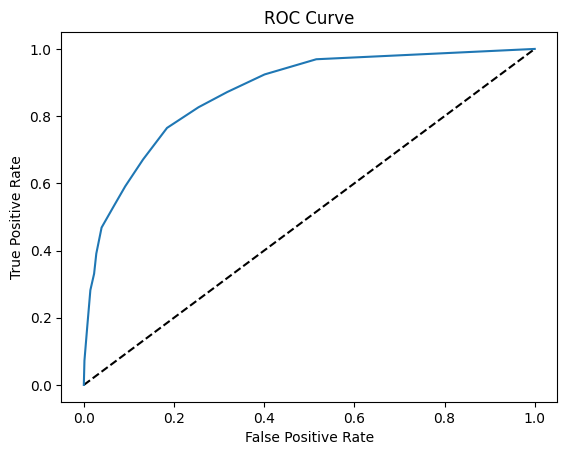

AUC score:  {0.8722011369785463}
              precision    recall  f1-score   support

         0.0       0.84      0.93      0.88      1447
         1.0       0.75      0.53      0.62       553

    accuracy                           0.82      2000
   macro avg       0.80      0.73      0.75      2000
weighted avg       0.82      0.82      0.81      2000



In [24]:
#AUC Score stuff is from scikit's website, such as: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
yprob = knn.predict_proba(xtest)[:, 1]
fpr, tpr, thresholds = roc_curve(ytest, yprob)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()
print('AUC score: ', {roc_auc_score(ytest, yprob)})
print(classification_report(ytest, ypredict))

In [25]:
#Sources Used:
#https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
#https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.GridSearchCV.html
#https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
#https://www.ibm.com/topics/knn
#https://developer.ibm.com/tutorials/learn-classification-algorithms-using-python-and-scikit-learn/